# Proyecto final

## Desarrollo de una herramienta analítica usando paquetes especializados para análisis de datos en Python

Para el desarrollo de este proyecto puedes utilizar cualquier librería externa. Te recomendamos leer por completo el enunciado antes de comenzar, de forma que tengas claro el propósito global de la actividad y puedas desarrollar tu solución apuntando a él desde el inicio.

Al desarrollar este proyecto pondrás a prueba tus habilidades para:

1. Identificar y abordar preguntas de negocio y de *analytics*.
2. Leer datos desde archivos y almacenarlos utilizando métodos de librerías especializadas.
3. Explorar, modificar, limpiar y unir objetos tablas de datos.
4. Implementar análisis combinando métricas descriptivas, visualización, filtrado y agrupación.
5. Implementar análisis basado en modelos estadísticos o de *machine learning*.

##  Contexto: desigualdad y factores de éxito en pruebas Saber 11 en Colombia

El ICFES es el Instituto Colombiano para el Fomento de la Educación Superior y está adscrito al Ministerio de Educación a nivel nacional. Como parte de sus funciones, el ICFES administra las pruebas Saber 11, las cuales evalúan a todos los estudiantes del país al final de su educación secundaria. El examen contiene preguntas que evalúan una variedad de áreas del conocimiento (ej., matemáticas, física, inglés, etc.) y se lleva a cabo dos veces al año, ajustándose a los diferentes calendarios académicos que siguen las instituciones educativas. Al momento de inscribirse a las pruebas, los estudiantes diligencian un formulario que recoge información sociodemográfica y relacionada con la institución a la que pertenecen. El fin es obtener información con respecto al desempeño de los estudiantes en la prueba y de sus características.

Al igual que otros países de la región, Colombia tiene grandes retos en términos de desigualdad, particularmente en el contexto de educación primaria y secundaria. Por esta razón, para el Estado colombiano es muy valioso el amplio registro de datos que el ICFES genera alrededor de las pruebas Saber 11, pues con ellos se pueden generar análisis sobre la calidad de la educación en el país y eventualmente dar lugar a recomendaciones sobre políticas públicas. En particular, la problemática a abordar en este caso de estudio es la desigualdad y factores de éxito en las pruebas Saber 11. 

Los objetivos de este caso de estudio son:

* Entender el contenido de los archivos de datos proporcionados sobre las pruebas Saber 11, generar un reporte acerca de sus características principales y seleccionar las partes de dicho contenido que podrían ser relevantes para el análisis.


* Identificar características de las variables de interés y relaciones entre ellas, por ejemplo, a través de agrupación, visualizaciones y estadísticas descriptivas.


* Proponer un modelo que busque relacionar las variables de interés con el desempeño de los estudiantes y concluir acerca de los posibles hallazgos que se podrían reportar para el *stakeholder*.


* Generar una herramienta que permita a un usuario interactuar con alguno de los parámetros del análisis realizado de forma relevante en el contexto del problema.

## Fase 1: obtener e inspeccionar archivos

En esta fase te harás una idea general del contenido de los datos y generarás un reporte al respecto (ej., imprimiendo mensajes, presentando tablas de resumen, etc.). Además, seleccionarás un segmento de los datos que consideres útil para realizar tu análisis.

Pautas generales:

* Utilizar una librería especializada para leer los archivos de datos y agregarlos según sea necesario (ej., utilizando los métodos `append` o `concat` si eliges cargarlos utilizando la librería `pandas`).
* Inspeccionar el archivo a partir de sus encabezados, columnas y descripciones de las variables según su tipo (ej., numéricas, categóricas).
* Declarar una estructura de datos (ej., una lista) para almacenar un subconjunto de variables que puedan ser relevantes para la problemática de interés.

Preguntas guía:

* ¿Qué dimensiones tienen los datos?
* ¿Con cuántos años y periodos de evaluación se cuenta?
* ¿Cuáles variables pueden ser de interés para la problemática planteada?
* ¿Qué porcentaje de datos faltantes o no válidos hay en las columnas de interés? ¿Qué planteas para manejarlos?

In [ ]:
https://www.datos.gov.co/Educaci-n/Resultados-nicos-Saber-11/kgxf-xxbe/about_data

In [1]:
import pandas as pd

# 1. Cargar el archivo CSV
df = pd.read_csv('data.csv')

# 2. Ver las dimensiones (filas, columnas)
print("Dimensiones del set de datos:", df.shape)

# 3. Dar un vistazo rápido a las primeras 5 filas
print(df.head())

C:\Users\rosem\AppData\Local\Temp\ipykernel_18104\631693011.py:4: DtypeWarning: Columns (45,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv')


Dimensiones del set de datos: (7109704, 51)
   PERIODO ESTU_TIPODOCUMENTO  ESTU_CONSECUTIVO COLE_AREA_UBICACION  \
0    20131                 CR  SB11201310000414              URBANO   
1    20194                 TI  SB11201940464873               RURAL   
2    20194                 TI  SB11201940464873               RURAL   
3    20122                 TI  SB11201220204399              URBANO   
4    20132                 TI  SB11201320464198              URBANO   

  COLE_BILINGUE COLE_CALENDARIO      COLE_CARACTER  \
0             N               B          ACADÉMICO   
1             N               A  TÉCNICO/ACADÉMICO   
2             N               A  TÉCNICO/ACADÉMICO   
3             N               A  TÉCNICO/ACADÉMICO   
4             N               A            TÉCNICO   

   COLE_COD_DANE_ESTABLECIMIENTO  COLE_COD_DANE_SEDE  \
0                   3.118480e+11        3.118480e+11   
1                   1.410160e+11        2.410160e+11   
2                   1.410160e+11    

In [2]:
import pandas as pd

# Suponiendo que ya cargaste tu DataFrame como 'df'
# df = pd.read_csv('data.csv')

# 1. Asegurar que la columna PERIODO se maneje como texto para poder extraer los dígitos fácilmente
df['PERIODO_STR'] = df['PERIODO'].astype(str)

# 2. Extraer el Año (los primeros 4 caracteres)
df['Anio'] = df['PERIODO_STR'].str[:4]

# 3. Extraer el Periodo del año (el último carácter)
df['Periodo_Evaluacion'] = df['PERIODO_STR'].str[-1]

# --- RESULTADOS ---

# Años únicos
anos_unicos = df['Anio'].unique()
print(f"--- ANÁLISIS DE TIEMPO ---")
print(f"• Total de años evaluados: {len(anos_unicos)}")
print(f"• Años detectados: {sorted(anos_unicos)}")

# Periodos únicos del año
periodos_unicos = df['Periodo_Evaluacion'].unique()
print(f"\n• Tipos de periodos de evaluación en el año: {sorted(periodos_unicos)}")
print("  (Donde típicamente 1 = Semestre 1, 2 = Semestre 2, etc.)")

# Combinaciones reales históricas (Ej: 2013-1, 2019-4...)
combinaciones_totales = df['PERIODO'].nunique()
print(f"\n• En total, cuentas con {combinaciones_totales} periodos de evaluación históricos diferentes.")

--- ANÁLISIS DE TIEMPO ---
• Total de años evaluados: 13
• Años detectados: ['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022']

• Tipos de periodos de evaluación en el año: ['1', '2', '4']
  (Donde típicamente 1 = Semestre 1, 2 = Semestre 2, etc.)

• En total, cuentas con 23 periodos de evaluación históricos diferentes.


In [3]:
import pandas as pd

# 1. Convertir la columna PERIODO a texto
periodos_str = df['PERIODO'].astype(str)

# 2. Extraer Años (primeros 4 dígitos) y Periodos (último dígito)
anos = periodos_str.str[:4].unique()
periodos = periodos_str.str[-1].unique()
total_combinaciones = df['PERIODO'].nunique()

# 3. Mostrar resultados
print(f"Años evaluados ({len(anos)}): {sorted(anos)}")
print(f"Periodos por año ({len(periodos)}): {sorted(periodos)}")
print(f"Total de evaluaciones históricas: {total_combinaciones}")

Años evaluados (13): ['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022']
Periodos por año (3): ['1', '2', '4']
Total de evaluaciones históricas: 23


In [4]:
import pandas as pd

# 1. Cargar el archivo data.csv
df = pd.read_csv('data.csv')

# 2. Extraer el año a partir de la columna PERIODO (los primeros 4 dígitos)
df['Anio'] = df['PERIODO'].astype(str).str[:4]

# 3. Definir los DOS años de interés (puedes cambiar estos valores por los que quieras)
anos_a_conservar = ['2019', '2020']

# 4. Filtrar para quedarnos únicamente con las filas de esos dos años
df_filtrado = df[df['Anio'].isin(anos_a_conservar)].copy()

# 5. Seleccionar solo las variables institucionales del colegio
variables_colegio = [
    'Anio',
    'PERIODO',
    'COLE_AREA_UBICACION',
    'COLE_CARACTER',
    'COLE_BILINGUE',
    'COLE_CALENDARIO'
]

# (Opcional) Agregar puntaje global si existe en tus datos
if 'PUNT_GLOBAL' in df_filtrado.columns:
    variables_colegio.append('PUNT_GLOBAL')

# Conservar solo las columnas de interés
df_colegios_dos_anos = df_filtrado[variables_colegio]

# --- COMPROBACIÓN ---
print("Nuevas dimensiones con solo 2 años:", df_colegios_dos_anos.shape)
print("Años presentes en el análisis:", df_colegios_dos_anos['Anio'].unique())

C:\Users\rosem\AppData\Local\Temp\ipykernel_18104\2149710262.py:4: DtypeWarning: Columns (45,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv')


Nuevas dimensiones con solo 2 años: (1124520, 7)
Años presentes en el análisis: ['2019' '2020']


In [5]:
# Suponiendo que ya tienes tu DataFrame filtrado: df_colegios_dos_anos

# 1. Contar datos nulos por columna
valores_nulos = df_colegios_dos_anos.isnull().sum()

# 2. Calcular el porcentaje de nulos
porcentaje_nulos = (valores_nulos / len(df_colegios_dos_anos)) * 100

# 3. Crear una tabla de resumen
resumen_faltantes = pd.DataFrame({
    'Datos Faltantes (Cantidad)': valores_nulos,
    'Porcentaje (%)': porcentaje_nulos.round(2)
})

print("Resumen de datos faltantes en variables de interés:")
print(resumen_faltantes)

Resumen de datos faltantes en variables de interés:
                     Datos Faltantes (Cantidad)  Porcentaje (%)
Anio                                          0            0.00
PERIODO                                       0            0.00
COLE_AREA_UBICACION                           0            0.00
COLE_CARACTER                             30729            2.73
COLE_BILINGUE                            179370           15.95
COLE_CALENDARIO                               0            0.00
PUNT_GLOBAL                                   0            0.00


In [6]:
# Hacemos una copia para no alterar el DataFrame original
df_limpio = df_colegios_dos_anos.copy()

# 1. Eliminar filas donde COLE_CARACTER sea nulo (solo el 2.73%)
df_limpio = df_limpio.dropna(subset=['COLE_CARACTER'])

# 2. Rellenar los nulos de COLE_BILINGUE con la categoría 'NO REPORTADO'
df_limpio['COLE_BILINGUE'] = df_limpio['COLE_BILINGUE'].fillna('NO REPORTADO')

# --- COMPROBACIÓN ---
print("Nuevas dimensiones del dataset limpio:", df_limpio.shape)
print("\nFaltantes por columna tras la limpieza:")
print(df_limpio.isnull().sum())

Nuevas dimensiones del dataset limpio: (1093791, 7)

Faltantes por columna tras la limpieza:
Anio                   0
PERIODO                0
COLE_AREA_UBICACION    0
COLE_CARACTER          0
COLE_BILINGUE          0
COLE_CALENDARIO        0
PUNT_GLOBAL            0
dtype: int64


## Fase 2: identificar características y relaciones en las variables

En esta fase realizarás análisis descriptivo para identificar posibles patrones o relaciones entre las variables de interés para la problemática planteada. Además, expondrás estadísticas descriptivas y visualizaciones para concluir al respecto de los patrones y las relaciones identificadas. Finalmente, elegirás el segmento de los datos sobre el cual profundizarás con tu análisis (este puede ser, o no, igual al seleccionado anteriormente).

Pautas generales:

* Calcular estadísticas descriptivas básicas (por lo menos, media/mediana y varianza/desviación) para cada variable sociodemográfica relevante en el contexto del problema.
* Utilizar librerías especializadas (ej., `matplotlib`, `seaborn`, etc.) para inspeccionar visualmente variables de interés. Los métodos `distplot`, `pairplot`, `boxplot`, o `violinplot`, entre otros, pueden ser útiles.
* Utilizar el método `groupby` de `pandas`, en conjunto con métodos de visualización, puede proveer evidencia del impacto de las variables sociodemográficas de interés sobre el desempeño de los estudiantes en la prueba.

C:\Users\rosem\AppData\Local\Temp\ipykernel_18104\4059255657.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


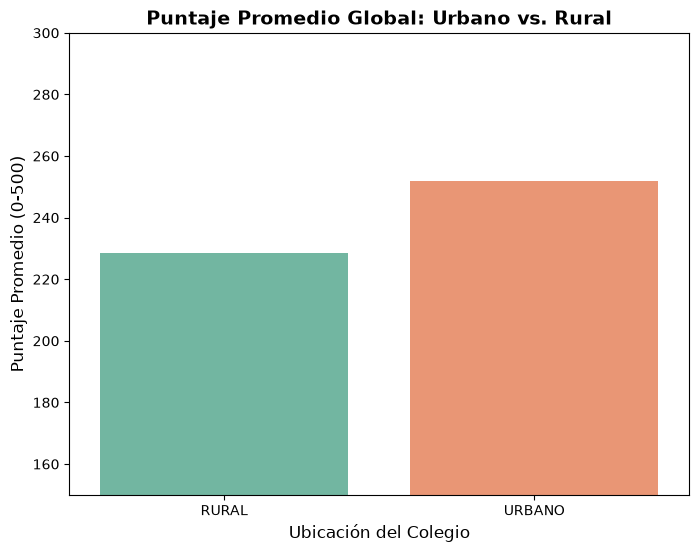

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configurar el tamaño de la imagen
plt.figure(figsize=(8, 6))

# 2. Crear la gráfica de barras 
# seaborn calcula automáticamente el promedio de PUNT_GLOBAL para cada categoría
sns.barplot(
    x='COLE_AREA_UBICACION', 
    y='PUNT_GLOBAL', 
    data=df_limpio, 
    palette='Set2',
    errorbar=None  # Quita las líneas de error para que la barra se vea más limpia
)

# 3. Personalizar el diseño y agregar etiquetas
plt.title('Puntaje Promedio Global: Urbano vs. Rural', fontsize=14, fontweight='bold')
plt.xlabel('Ubicación del Colegio', fontsize=12)
plt.ylabel('Puntaje Promedio (0-500)', fontsize=12)

# Ajustar los límites del eje Y para apreciar mejor la diferencia (ej. de 150 a 300)
plt.ylim(150, 300)

# 4. Mostrar la gráfica
plt.show()

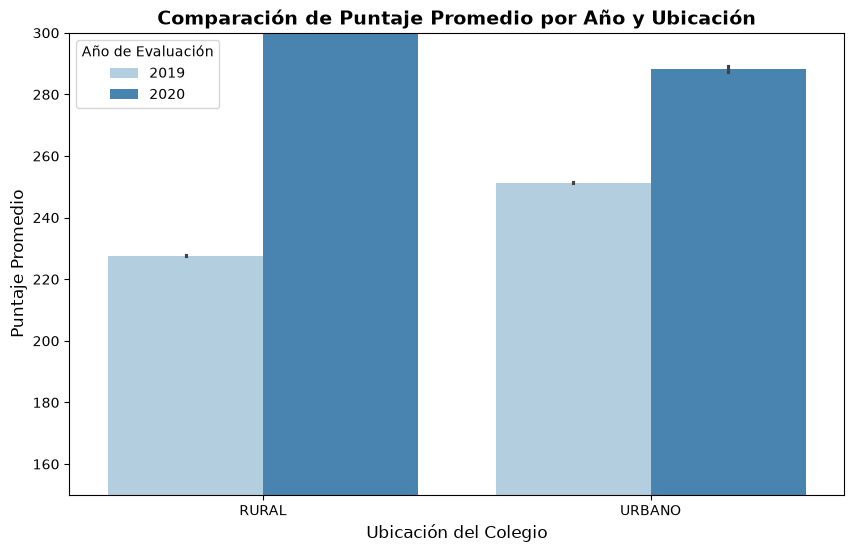

In [11]:
plt.figure(figsize=(10, 6))

# Graficar comparando por ubicación y año de evaluación
sns.barplot(
    x='COLE_AREA_UBICACION', 
    y='PUNT_GLOBAL', 
    hue='Anio',  # Divide las barras por cada año que seleccionaste
    data=df_limpio, 
    palette='Blues'
)

plt.title('Comparación de Puntaje Promedio por Año y Ubicación', fontsize=14, fontweight='bold')
plt.xlabel('Ubicación del Colegio', fontsize=12)
plt.ylabel('Puntaje Promedio', fontsize=12)
plt.ylim(150, 300)
plt.legend(title='Año de Evaluación')

plt.show()

C:\Users\rosem\AppData\Local\Temp\ipykernel_18104\3498675304.py:6: DtypeWarning: Columns (45,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv')


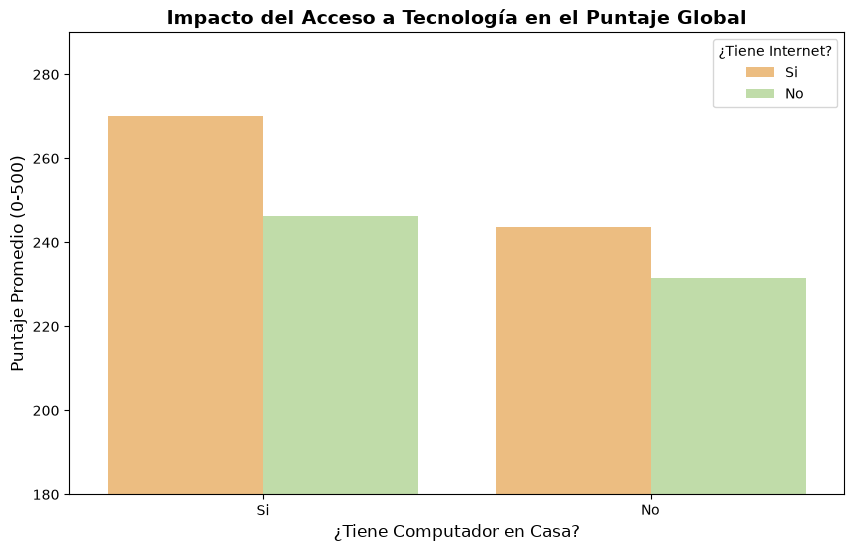

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar datos y extraer las columnas necesarias
df = pd.read_csv('data.csv')
df_socio = df[['FAMI_TIENECOMPUTADOR', 'FAMI_TIENEINTERNET', 'PUNT_GLOBAL']].dropna()

# 2. Configurar el tamaño del gráfico
plt.figure(figsize=(10, 6))

# 3. Crear la gráfica de barras agrupadas
sns.barplot(
    x='FAMI_TIENECOMPUTADOR',
    y='PUNT_GLOBAL',
    hue='FAMI_TIENEINTERNET',
    data=df_socio,
    palette='Spectral',
    errorbar=None  # Limpia la barra de líneas de error
)

# 4. Personalizar títulos y etiquetas
plt.title('Impacto del Acceso a Tecnología en el Puntaje Global', fontsize=14, fontweight='bold')
plt.xlabel('¿Tiene Computador en Casa?', fontsize=12)
plt.ylabel('Puntaje Promedio (0-500)', fontsize=12)
plt.legend(title='¿Tiene Internet?')

# Ajustar el límite de visualización en el eje Y para que la diferencia sea más evidente
plt.ylim(180, 290)

# 5. Mostrar el gráfico
plt.show()

In [16]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 1. Cargar y preparar los datos (asegúrate de incluir las variables necesarias)
df = pd.read_csv('data.csv')

# Limpiar nulos únicamente en las dos columnas que usaremos
df_anova = df[['FAMI_TIENEINTERNET', 'PUNT_GLOBAL']].dropna()

# 2. Ajustar el modelo de regresión lineal (Mínimos Cuadrados Ordinarios - OLS)
# Usamos C() para indicarle a statsmodels que tratará a la variable como categórica
modelo = ols('PUNT_GLOBAL ~ C(FAMI_TIENEINTERNET)', data=df_anova).fit()

# 3. Crear la tabla ANOVA
tabla_anova = sm.stats.anova_lm(modelo, typ=2)

print("--- TABLA DE RESULTADOS ANOVA ---")
print(tabla_anova)

C:\Users\rosem\AppData\Local\Temp\ipykernel_18104\807044940.py:6: DtypeWarning: Columns (45,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv')


--- TABLA DE RESULTADOS ANOVA ---
                             sum_sq         df              F  PR(>F)
C(FAMI_TIENEINTERNET)  9.535197e+08        1.0  414852.312935     0.0
Residual               9.970374e+09  4337858.0            NaN     NaN


In [17]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Realizar la prueba de comparación múltiple de Tukey
tukey = pairwise_tukeyhsd(endog=df_anova['PUNT_GLOBAL'],
                          groups=df_anova['FAMI_TIENEINTERNET'],
                          alpha=0.05)

print("\n--- PRUEBA POST-HOC DE TUKEY ---")
print(tukey)


--- PRUEBA POST-HOC DE TUKEY ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
    No     Si  30.3525   0.0 30.2602 30.4449   True
---------------------------------------------------


Preguntas guía:

* ¿Hay patrones de interés en las distribuciones de las variables o en las relaciones entre ellas?
* ¿Consideras que existe algún impacto significativo de variables sociodemográficas en los puntajes globales o por área?
* ¿Sobre cuáles variables harías un análisis más profundo?

## Fase 3: abordar relación variables-desempeño a través de un modelo

En esta fase propondrás, implementarás y reportarás el desempeño de uno o más modelos (al menos uno predictivo) que busquen explicar las relaciones entre factores sociodemográficos y el desempeño en la prueba. Además, concluirás con respecto a la validez de al menos un modelo y los posibles hallazgos que se podrían reportar para el *stakeholder*.

Pautas generales:

* Seleccionar variables y proponer modelos acordes a estas y al contexto del problema.
* Utilizar librerías especializadas (ej., `statsmodels`, `sklearn`, etc.) para indagar sobre los aspectos que contribuyen al éxito de los estudiantes. Los módulos correspondientes a regresión lineal y regresión logística pueden ser útiles.
* Asegurar el cumplimiento de los supuestos y buenas prácticas de cada modelo.
* Utilizar las métricas de evaluación de desempeño (disponibles en las librerías especilizadas), para concluir sobre la validez de los modelos propuestos.

Preguntas guía:

* ¿Existe algún sub-conjunto de variables socio-demográficas que explique razonablemente bien el desempeño de los estudiantes en la prueba?

In [18]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 1. Cargar el DataFrame original
df = pd.read_csv('data.csv')

# 2. Seleccionar el subconjunto sociodemográfico clave y limpiar nulos
variables_socio = [
    'FAMI_EDUCACIONMADRE', 
    'FAMI_TIENEINTERNET', 
    'FAMI_TIENECOMPUTADOR', 
    'FAMI_ESTRATOVIVIENDA',
    'PUNT_GLOBAL'
]
df_modelo = df[variables_socio].dropna()

# 3. Ajustar la Regresión Múltiple
# Usamos C() para las variables que son categóricas (texto o estrato)
formula = 'PUNT_GLOBAL ~ C(FAMI_EDUCACIONMADRE) + C(FAMI_TIENEINTERNET) + C(FAMI_TIENECOMPUTADOR) + C(FAMI_ESTRATOVIVIENDA)'
modelo_regresion = ols(formula, data=df_modelo).fit()

# 4. Mostrar el resumen estadístico
print(modelo_regresion.summary())

C:\Users\rosem\AppData\Local\Temp\ipykernel_18104\2898170796.py:6: DtypeWarning: Columns (45,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv')


                            OLS Regression Results                            
Dep. Variable:            PUNT_GLOBAL   R-squared:                       0.224
Model:                            OLS   Adj. R-squared:                  0.224
Method:                 Least Squares   F-statistic:                 6.462e+04
Date:                Wed, 15 Jul 2026   Prob (F-statistic):               0.00
Time:                        12:03:41   Log-Likelihood:            -2.2204e+07
No. Observations:             4264655   AIC:                         4.441e+07
Df Residuals:                 4264635   BIC:                         4.441e+07
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

## Fase 4

Deberás elegir y realizar una de las dos alternativas que se encuentran a continuación.

### Alternativa 1: desarrollar una herramienta interactiva de análisis

En esta fase desarrollarás, a partir de alguno de los análisis realizados, una herramienta interactiva que sea relevante en el contexto del problema, acompañada de las instrucciones necesarias para que un usuario la pueda utilizar.

Pautas generales:

* Seleccionar uno de los análisis previos que pueda verse enriquecido con alguna característica de interactividad.
* Seleccionar el/los parámetro(s) que el usuario podrá cambiar.
* Desarrollar las funciones que se deben ejecutar con cada acción del usuario.
* Utilizar una librería especializada (ej., `ipywidgets`, `panel`, etc.) para implementar la herramienta.

Preguntas guía:

* ¿Cuál o cuáles preguntas podrá hacerle el usuario a la herramienta y cómo aporta la respuesta al análisis?
* ¿Qué aprendizajes clave puede explorar u obtener el usuario con esta herramienta?

In [21]:
import pandas as pd
import ipywidgets as widgets
from ipywidgets import interactive, HBox, VBox
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar el dataset original (limitemos de una vez a 2 años de interés como definiste)
df_original = pd.read_csv('data.csv')
df_original['Anio'] = df_original['PERIODO'].astype(str).str[:4]

# Filtramos tus 2 años específicos (ejemplo: 2019 y 2020)
anos_interes = ['2019', '2020']
df_dos_anos = df_original[df_original['Anio'].isin(anos_interes)].copy()

# 2. SELECCIONAR TODAS LAS VARIABLES DE INTERÉS (Institucionales + Sociodemográficas)
variables_analisis = [
    'Anio',
    'PERIODO',
    'COLE_AREA_UBICACION',
    'COLE_CARACTER',
    'COLE_BILINGUE',
    'COLE_CALENDARIO',
    'FAMI_TIENECOMPUTADOR',
    'FAMI_TIENEINTERNET',
    'PUNT_GLOBAL'
]

# Creamos el subconjunto de trabajo eliminando filas con todo nulo
df_trabajo = df_dos_anos[variables_analisis].copy()

# 3. APLICAR LA LIMPIEZA PLANTEADA
# Eliminamos filas nulas en COLE_CARACTER (2.73% de pérdida)
df_limpio = df_trabajo.dropna(subset=['COLE_CARACTER', 'PUNT_GLOBAL'])

# Reemplazamos los nulos en bilingüismo e internet por una etiqueta para no perder filas
df_limpio['COLE_BILINGUE'] = df_limpio['COLE_BILINGUE'].fillna('NO REPORTADO')
df_limpio['FAMI_TIENEINTERNET'] = df_limpio['FAMI_TIENEINTERNET'].fillna('NO REPORTADO')
df_limpio['FAMI_TIENECOMPUTADOR'] = df_limpio['FAMI_TIENECOMPUTADOR'].fillna('NO REPORTADO')


# ==========================================
# 4. DASHBOARD INTERACTIVO (CORREGIDO)
# ==========================================

def actualizar_dashboard(anio, variable_x, comparar_por):
    # Filtrar por el año seleccionado por el widget
    datos_filtrados = df_limpio[df_limpio['Anio'] == anio]
    
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    # Crear la gráfica de barras con las variables seguras que ya existen en df_limpio
    sns.barplot(
        x=variable_x, 
        y='PUNT_GLOBAL', 
        hue=comparar_por, 
        data=datos_filtrados, 
        palette='coolwarm',
        errorbar=None
    )
    
    # Estética del gráfico
    plt.title(f'Análisis de Puntaje Global en el Año {anio}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel(variable_x.replace('_', ' ').title(), fontsize=12)
    plt.ylabel('Puntaje Promedio (0-500)', fontsize=12)
    plt.ylim(150, 310)  
    plt.legend(title=comparar_por.replace('_', ' ').title(), loc='upper right')
    
    # Etiquetas con valores sobre las barras
    ax = plt.gca()
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():.1f}', 
                        (p.get_x() + p.get_width() / 2., p.get_height() - 15), 
                        ha='center', va='center', 
                        xytext=(0, 9), 
                        textcoords='offset points', 
                        fontsize=10, color='white', fontweight='bold')
            
    plt.tight_layout()
    plt.show()

# 5. Configurar los menús desplegables
menu_anio = widgets.Dropdown(
    options=sorted(df_limpio['Anio'].unique()),
    description='Año:',
    style={'description_width': 'initial'}
)

menu_x = widgets.Dropdown(
    options={
        'Ubicación del Colegio': 'COLE_AREA_UBICACION',
        'Carácter del Colegio': 'COLE_CARACTER',
        '¿Tiene Computador?': 'FAMI_TIENECOMPUTADOR'
    },
    value='COLE_AREA_UBICACION',
    description='Eje X (Agrupar):',
    style={'description_width': 'initial'}
)

menu_hue = widgets.Dropdown(
    options={
        'Acceso a Internet': 'FAMI_TIENEINTERNET',
        'Colegio Bilingüe': 'COLE_BILINGUE',
        'Calendario Escolar': 'COLE_CALENDARIO'
    },
    value='FAMI_TIENEINTERNET',
    description='Comparar por (Color):',
    style={'description_width': 'initial'}
)

# 6. Ejecutar e integrar los controles
dashboard = interactive(
    actualizar_dashboard, 
    anio=menu_anio, 
    variable_x=menu_x, 
    comparar_por=menu_hue
)

controles = HBox(dashboard.children[:-1])
grafica = dashboard.children[-1]
VBox([controles, grafica])

C:\Users\rosem\AppData\Local\Temp\ipykernel_18104\1842474362.py:8: DtypeWarning: Columns (45,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df_original = pd.read_csv('data.csv')
C:\Users\rosem\AppData\Local\Temp\ipykernel_18104\1842474362.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio['COLE_BILINGUE'] = df_limpio['COLE_BILINGUE'].fillna('NO REPORTADO')
C:\Users\rosem\AppData\Local\Temp\ipykernel_18104\1842474362.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-c

## Referencias

*  J. VanderPlas (2016) *Python Data Science Handbook: Essential Tools for Working with Data* O'Reilly Media, Inc.
*  scikit-learn developers . (2020). Demo of DBSCAN clustering algorithm. 11 Diciembre 2020, de scikit-learn <br> https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html#sphx-glr-auto-examples-cluster-plot-dbscan-py